<h1>Bitcoin Predictability: FFT vs Wavelets (Daily Data) or Is it possible to predict next day price based on Wavelets or FFT</h1>


In this project we'll try to figure out is it possible to forecast next day Bitcoin returns based on those 2 methods:

1. Fourier Transform (FFT) features
2. Wavelet Transform features (Continuous Wavelet Transform from library `scipy`)

We use daily BTC-USD data from Yahoo Finance via `yfinance`, and keep the modeling lightweight using linear/regularized models from `scikit-learn`.

 Our goal is to compare FFT vs Wavelet features in an out-of-sample setting and conclude whether daily BTC moves show meaningful predictability if possible

<hr/>


- We use a **walk-forward style split** (time-series split) to reduce look-ahead bias.


In [46]:
import yfinance as yf
import pandas as pd
import numpy as np

# Signal processing
from scipy import fft
from scipy import signal
import pywt

# Modeling
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, roc_auc_score
)

# Plotting
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)

symbol = "BTC-USD"
start = "2014-01-01"

df = yf.download(symbol, start=start, auto_adjust=False, progress=False)
df = df[['Close']].dropna()
df['log_return'] = np.log(df['Close']).diff()
df = df.dropna()

df.head(), df.tail(), df.shape


(Price            Close log_return
 Ticker         BTC-USD           
 Date                             
 2014-09-18  424.440002  -0.074643
 2014-09-19  394.795990  -0.072402
 2014-09-20  408.903992   0.035111
 2014-09-21  398.821014  -0.024968
 2014-09-22  402.152008   0.008317,
 Price              Close log_return
 Ticker           BTC-USD           
 Date                               
 2026-03-11  70204.882812   0.003967
 2026-03-12  70493.460938   0.004102
 2026-03-13  70968.265625   0.006713
 2026-03-14  71214.625000   0.003465
 2026-03-15  71640.187500   0.005958,
 (4197, 2))

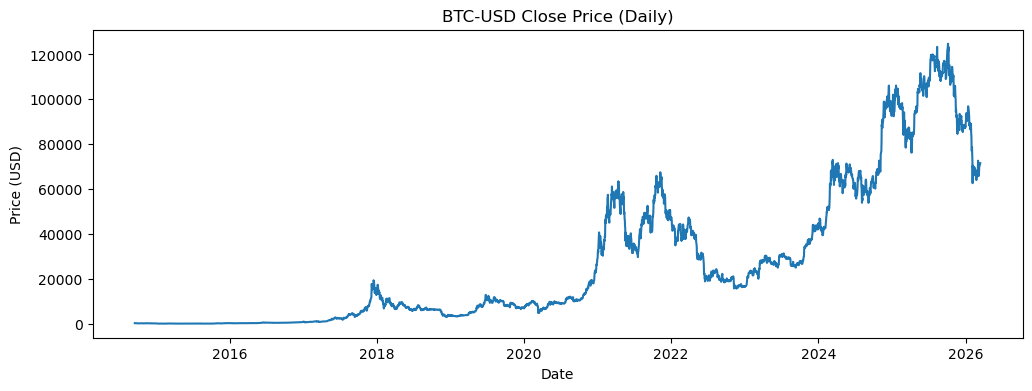

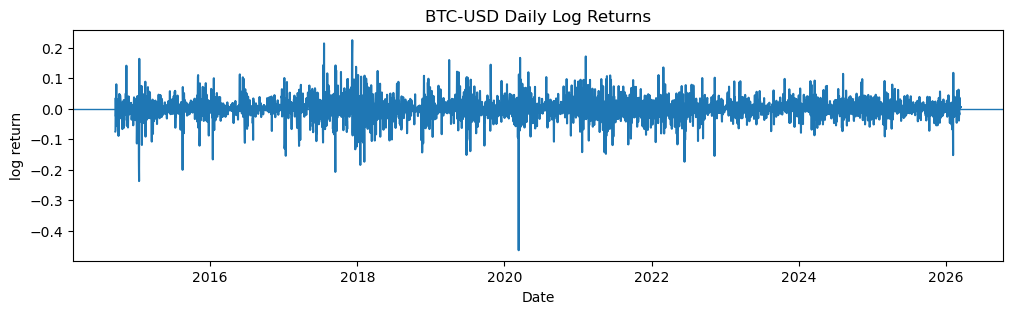

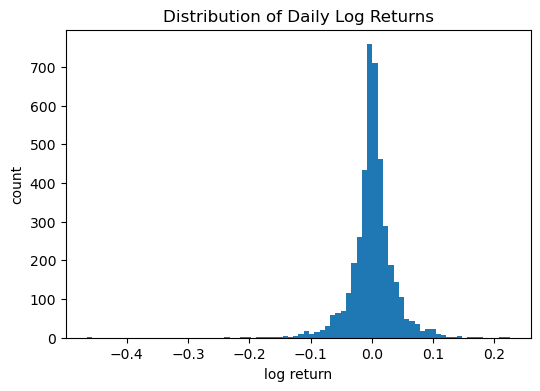

In [47]:
# Quick sanity plots: price and daily log returns
fig = plt.figure(figsize=(12,4))
plt.plot(df.index, df['Close'])
plt.title("BTC-USD Close Price (Daily)")
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.show()

fig = plt.figure(figsize=(12,3))
plt.plot(df.index, df['log_return'])
plt.title("BTC-USD Daily Log Returns")
plt.xlabel("Date"); plt.ylabel("log return")
plt.axhline(0, linewidth=1)
plt.show()

fig = plt.figure(figsize=(6,4))
plt.hist(df['log_return'], bins=80)
plt.title("Distribution of Daily Log Returns")
plt.xlabel("log return"); plt.ylabel("count")
plt.show()

## 2) Problem setup

We build features from a rolling window of past returns

$$
\{r_{t-W+1}, \dots, r_t\}
$$

and predict

$$
r_{t+1}.
$$

Let \(\mathbf{x}_t\) be features computed at time \(t\), using only information available up to \(t\).

**Why features?**  
Raw returns are noisy; FFT and Wavelets summarize frequency/time-scale structure in the recent window.

We'll compare:

- **FFT features:** magnitude spectrum of the rolling window
- **Wavelet features:** average absolute CWT coefficients across a set of scales

We also include a simple baseline: predict 0 return (regression) / predict majority class (classification).